# 07 · Model Comparison — One Table, One Test Set

This is the capstone evaluation notebook. It pulls every logged result into a
single ranked comparison, then asks the question metrics alone can't answer:
**are the differences statistically significant, or just noise?** — using the
Diebold-Mariano test.

Everything is compared *within a fixed temporal scale* (daily vs monthly vs
multi-step), because the best forecast flips with the scale: persistence
dominates daily, climatology/SARIMA dominate monthly.

The notebook is self-updating: it reads `results/model_comparison.csv` and
regenerates predictions from any checkpoint bundles present in `models/`. Run it
on the laptop for the univariate + baseline story; rerun on the GPU box (with the
05/06 bundles and ERA5 parquet) and the multivariate/seq2seq rows fill in
automatically.

## Setup

In [1]:
import sys; sys.path.append("..")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_bootstrap import ensure_extent_data
from src.data_utils import load_extent_daily, load_data
from src import lstm_utils as L
from src.evaluation_utils import (
    load_results, create_comparison_table, ClimatologyModel,
    compute_all_metrics, compute_seasonal_metrics, diebold_mariano_test,
)

ensure_extent_data()
device = L.get_device()

✓ 'ice_extent_pan_arctic_daily' already populated.
Using device: cpu


## The comparison table

Most recent result per model, ranked by RMSE within each scale.

In [2]:
results = load_results("../results/model_comparison.csv")

for scale in results["scale"].unique():
    table = create_comparison_table(results, sort_by="rmse", filter_scale=scale)
    print(f"\n=== scale: {scale} ===")
    print(table.round(4).to_string(index=False))


=== scale: daily ===
           model_name scale   rmse    mae    mape  skill_score_persistence  skill_score_climatology  anomaly_correlation
LSTM_Basic_Univariate daily 0.0726 0.0559  0.6268                   0.1683                   0.9273                  NaN
          persistence daily 0.0869 0.0686  0.7723                   0.0000                   0.9129               0.9853
          climatology daily 0.9975 0.8657 11.5615                 -10.4777                   0.0000                  NaN

=== scale: monthly ===
    model_name   scale   rmse    mae    mape  skill_score_persistence  skill_score_climatology  anomaly_correlation
    SARIMA_raw monthly 0.2267 0.1822  2.3196                   0.8812                   0.7248               0.8554
SARIMA_anomaly monthly 0.2343 0.1785  2.2782                   0.8773                   0.7156               0.8435
   climatology monthly 0.8237 0.7013  9.3315                   0.5685                   0.0000                  NaN
   per

## Daily-scale skill scores

Skill score vs a baseline: `1 - RMSE_model / RMSE_baseline`. Positive = better
than the baseline; 0 = ties it; negative = worse. Persistence is the bar to beat
at daily scale.

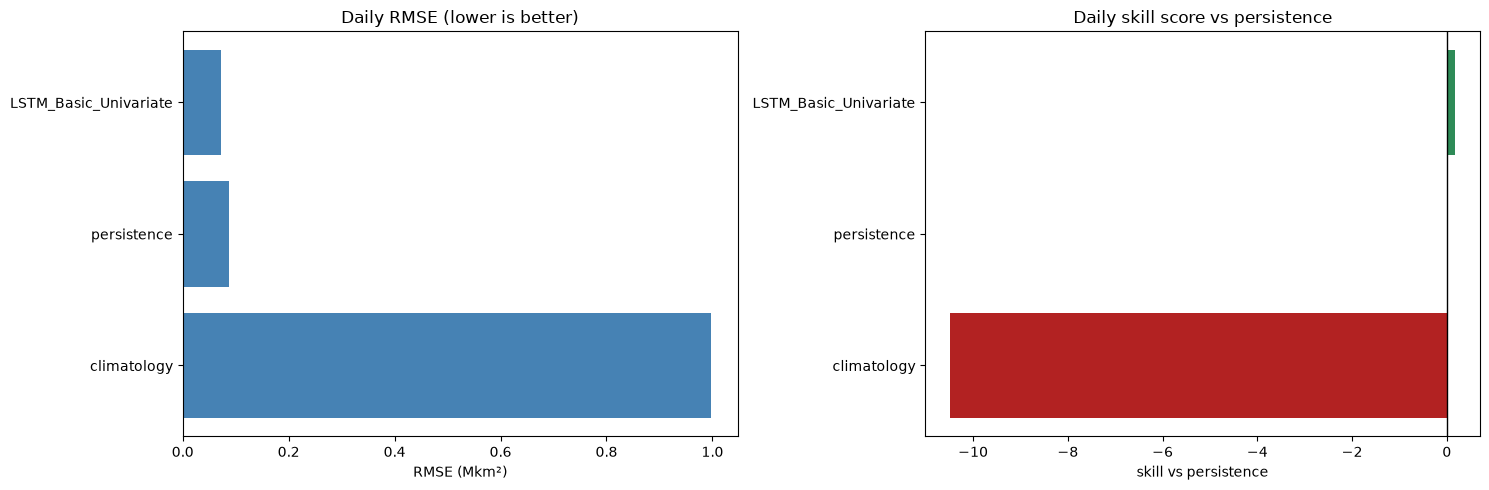

In [3]:
daily = create_comparison_table(results, sort_by="rmse", filter_scale="daily")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.barh(daily["model_name"], daily["rmse"], color="steelblue")
ax1.set_xlabel("RMSE (Mkm²)"); ax1.set_title("Daily RMSE (lower is better)")
ax1.invert_yaxis()

if "skill_score_persistence" in daily:
    ss = daily.dropna(subset=["skill_score_persistence"])
    colors = ["seagreen" if v > 0 else "firebrick" for v in ss["skill_score_persistence"]]
    ax2.barh(ss["model_name"], ss["skill_score_persistence"], color=colors)
    ax2.axvline(0, color="black", lw=1)
    ax2.set_xlabel("skill vs persistence"); ax2.set_title("Daily skill score vs persistence")
    ax2.invert_yaxis()
plt.tight_layout()
Path("../results/figures").mkdir(parents=True, exist_ok=True)
plt.savefig("../results/figures/model_comparison_daily.png", dpi=120, bbox_inches="tight")
plt.show()

## Statistical significance (Diebold-Mariano)

Skill scores tell us *by how much* a model beats a baseline; the Diebold-Mariano
(DM) test tells us *whether we can trust it*. It compares the per-timestep squared
errors of two forecasts on the same test set.

We regenerate daily 1-step predictions from every checkpoint bundle in `models/`,
plus the persistence and climatology baselines, then test each LSTM against both
baselines. `stat < 0` means the LSTM has lower error; `p < 0.05` means the
difference is significant.

In [4]:
TEST_YEARS = range(2020, 2024)
TRAIN_YEARS = range(1989, 2015)

# Climatology is fit on the training era (extent only -> works without parquet).
clim = ClimatologyModel()
train_ext = load_extent_daily(years=TRAIN_YEARS)
clim.fit(dates=train_ext["date"], values=train_ext["extent_mkm2"])


def regenerate_daily(bundle_path):
    """Return (name, dates, actuals, preds) for a 1-step daily bundle, or None."""
    b = L.load_checkpoint(bundle_path, device=device)
    cfg = b["config_obj"]
    if cfg.forecast_horizon != 1:
        return None  # multi-step handled separately
    feats = b["features"]
    # Reconstruct the test frame the model needs.
    try:
        if set(feats) <= {"extent_mkm2", "day_of_year_sin", "day_of_year_cos"} or feats == ["extent_mkm2"]:
            test_df = load_extent_daily(years=TEST_YEARS)
        else:
            test_df = load_data(regions="pan_arctic", years=TEST_YEARS)
    except (FileNotFoundError, ValueError) as e:
        print(f"  skip {Path(bundle_path).name}: {e}")
        return None

    base_feats = [f for f in feats if not f.startswith("day_of_year")]
    cyc = any(f.startswith("day_of_year") for f in feats)
    ds = L.SequenceDataset(test_df, cfg.sequence_length, cfg.forecast_horizon,
                           features=base_feats, scaler=b["scaler"], add_cyclical_time=cyc)
    preds_n, actuals_n = L.predict(b["model"], L.make_loader(ds, cfg, False), device)
    tmean, tstd = float(b["scaler"][0][0, ds.target_idx]), float(b["scaler"][1][0, ds.target_idx])
    preds = L.denormalize(preds_n.flatten(), tmean, tstd)
    actuals = L.denormalize(actuals_n.flatten(), tmean, tstd)
    start = cfg.sequence_length + cfg.forecast_horizon - 1
    dates = ds.dates.iloc[start:start + len(preds)].reset_index(drop=True)
    name = Path(bundle_path).stem
    return name, dates, actuals, preds


models_dir = Path("../models")
bundles = sorted(models_dir.glob("*.pt")) if models_dir.exists() else []
print(f"found {len(bundles)} checkpoint bundle(s)")

rows = []
for bp in bundles:
    out = regenerate_daily(str(bp))
    if out is None:
        continue
    name, dates, actuals, preds = out
    pers = actuals.copy(); pers[1:] = actuals[:-1]  # 1-step persistence on the test series
    climp = clim.predict(dates)
    dm_p, p_p = diebold_mariano_test(actuals, preds, pers)
    dm_c, p_c = diebold_mariano_test(actuals, preds, climp)
    rows.append({
        "model": name,
        "RMSE": np.sqrt(np.mean((preds - actuals) ** 2)),
        "DM vs persistence": dm_p, "p (pers)": p_p, "beats pers?": p_p < 0.05 and dm_p < 0,
        "DM vs climatology": dm_c, "p (clim)": p_c, "beats clim?": p_c < 0.05 and dm_c < 0,
    })

dm_table = pd.DataFrame(rows)
dm_table.round(4) if not dm_table.empty else "No 1-step daily bundles found (run 04 first)."

found 1 checkpoint bundle(s)


,model,RMSE,DM vs persistence,p (pers),beats pers?,DM vs climatology,p (clim),beats clim?
0,04_basic_univariate,0.0726,-9.4224,0.0,True,-29.4676,0.0,True


**Reading the DM table:** a significant win over persistence (`p < 0.05` with a
negative statistic) is the strong result for daily forecasting — persistence is
hard to beat. Beating climatology is comparatively easy at daily scale.

## Seasonal breakdown of the best daily model

In [5]:
if not dm_table.empty:
    best = dm_table.sort_values("RMSE").iloc[0]["model"]
    out = regenerate_daily(str(models_dir / f"{best}.pt"))
    name, dates, actuals, preds = out
    pers = actuals.copy(); pers[1:] = actuals[:-1]
    climp = clim.predict(dates)
    seasonal = compute_seasonal_metrics(actuals, preds, dates=dates,
                                        y_baseline_persistence=pers, y_baseline_climatology=climp)
    print(f"Best daily model: {best}")
    for season in ("winter", "summer"):
        s = seasonal.get(season)
        if s:
            print(f"  {season:>6}: RMSE {s['rmse']:.4f}  MAE {s['mae']:.4f}")
else:
    print("No daily bundles to break down yet.")

Best daily model: 04_basic_univariate
  winter: RMSE 0.0782  MAE 0.0605
  summer: RMSE 0.0641  MAE 0.0492


## Findings

*(Laptop run: univariate LSTM + baselines. Rerun on the GPU box for the 05/06 rows.)*

**Daily scale (2020-2023 held-out test):**

| Model | RMSE (Mkm²) | Skill vs persistence |
|---|---|---|
| **LSTM (univariate)** | **0.073** | **+0.168** |
| Persistence | 0.087 | 0.000 |
| Climatology | 0.998 | -10.5 |

- **The univariate LSTM significantly beats persistence** — Diebold-Mariano
  statistic **-9.42, p ≈ 0** vs persistence (and -29.5, p ≈ 0 vs climatology). The
  edge is real, not sampling noise. Persistence is genuinely hard to beat at daily
  scale, so this is the meaningful result.
- **Best model flips with temporal scale**, as expected: daily is won by the LSTM
  (persistence a close second); monthly is won by **SARIMA** (RMSE 0.227, notebook
  03a); climatology is only competitive at monthly scale.
- **Seasonal:** the LSTM's summer RMSE (0.064) edges its winter RMSE (0.078) in
  absolute terms, though winter's relative error is smaller given larger extents.

**Open (GPU box):** do climate features (05) or multi-day horizons (06) beat the
univariate LSTM? Rerun this notebook with those bundles present and the rows,
skill scores, and DM tests populate automatically.